Original Shape: (95837, 23)
Sampled Shape: (5000, 23)
Final Feature Shape: (5000, 10)


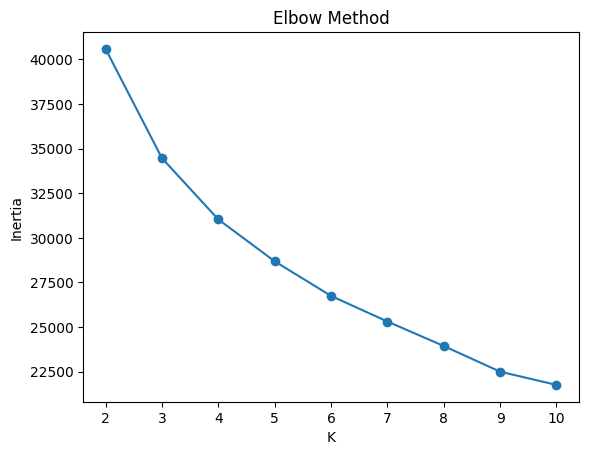

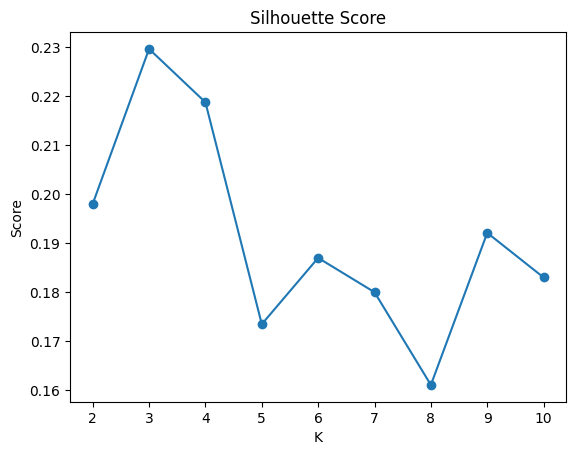


Cluster Counts:
Cluster
0    2379
3    1584
1     600
2     437
Name: count, dtype: int64

Silhouette Score: 0.23668770963243158
Davies-Bouldin Score: 1.5191606285791113


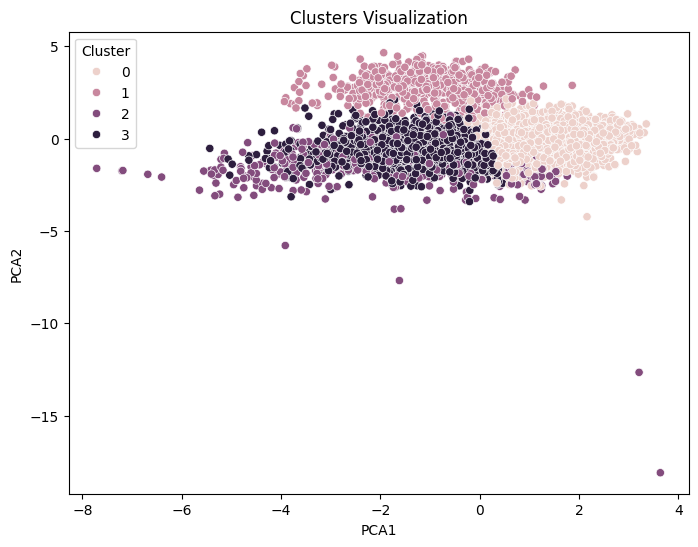


Cluster Summary:
         danceability    energy   loudness  speechiness  acousticness  \
Cluster                                                                 
0            0.640734  0.714944  -7.349090     0.076184      0.237370   
1            0.667293  0.463483 -13.442385     0.840587      0.583607   
2            0.499554  0.428607 -13.652011     0.059359      0.634410   
3            0.510985  0.348857 -12.038873     0.056471      0.695976   

         instrumentalness  liveness   valence       tempo    duration_ms  
Cluster                                                                   
0                0.017320  0.206668  0.696814  124.635248  224282.165616  
1                0.002694  0.433498  0.591452  101.104315   95124.865000  
2                0.811657  0.178668  0.458182  114.325799  245738.883295  
3                0.018035  0.189366  0.429724  113.919457  224126.340909  


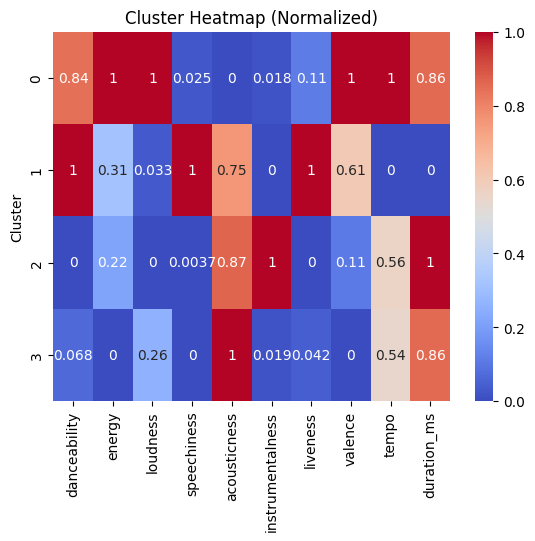


✅ PROJECT COMPLETED SUCCESSFULLY


In [2]:
# =========================================
# 1. IMPORT LIBRARIES
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")


# =========================================
# 2. LOAD DATA
# =========================================
df = pd.read_csv("single_genre_artists.csv")

print("Original Shape:", df.shape)

# =========================================
# 3. SAMPLE DATA (VERY IMPORTANT)
# =========================================
df = df.sample(n=5000, random_state=42)

print("Sampled Shape:", df.shape)


# =========================================
# 4. CLEAN DATA
# =========================================
df = df.drop_duplicates()

df = df.drop(columns=["track_id", "track_name", "artist_name"], errors='ignore')


# =========================================
# 5. FEATURE SELECTION (ONLY 10 FEATURES)
# =========================================
features = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo', 'duration_ms'
]

X = df[features].copy()

# Ensure numeric
X = X.apply(pd.to_numeric, errors='coerce')
X = X.dropna()

print("Final Feature Shape:", X.shape)


# =========================================
# 6. SCALING
# =========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# =========================================
# 7. ELBOW METHOD
# =========================================
inertia = []
k_range = range(2, 11)

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()


# =========================================
# 8. SILHOUETTE SCORE (SAFE)
# =========================================
sil_scores = []

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels, sample_size=500)
    sil_scores.append(score)

plt.plot(k_range, sil_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("K")
plt.ylabel("Score")
plt.show()


# =========================================
# 9. FINAL MODEL
# =========================================
k = 4

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

df = df.loc[X.index]   # align rows
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("\nCluster Counts:")
print(df['Cluster'].value_counts())


# =========================================
# 10. EVALUATION
# =========================================
sil = silhouette_score(X_scaled, df['Cluster'], sample_size=500)
db = davies_bouldin_score(X_scaled, df['Cluster'])

print("\nSilhouette Score:", sil)
print("Davies-Bouldin Score:", db)


# =========================================
# 11. PCA VISUALIZATION
# =========================================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster')
plt.title("Clusters Visualization")
plt.show()


# =========================================
# 12. CLUSTER ANALYSIS
# =========================================
cluster_summary = df.groupby('Cluster')[features].mean()

# Print actual values
print("\nCluster Summary:")
print(cluster_summary)

# Normalized heatmap for better visualization
cluster_summary_scaled = (cluster_summary - cluster_summary.min()) / (cluster_summary.max() - cluster_summary.min())

sns.heatmap(cluster_summary_scaled, annot=True, cmap='coolwarm')
plt.title("Cluster Heatmap (Normalized)")
plt.show()


# =========================================
# 13. SAVE OUTPUT
# =========================================
df.to_csv("amazon_music_clusters.csv", index=False)

print("\n✅ PROJECT COMPLETED SUCCESSFULLY")